In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Dataset path
data_path = "../data"

# Get all class names
classes = sorted(os.listdir(data_path))

print("Classes:")
for class_name in classes:
    print(class_name)

Classes:
cardboard
glass
metal
paper
plastic
trash


In [3]:
# Count images in each class

class_counts = {}

for class_name in classes:
    class_path = os.path.join(data_path, class_name)
    
    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    
    class_counts[class_name] = image_count

print("Image count for each class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")
    
print(f"\nTotal images: {sum(class_counts.values())}")

Image count for each class:
cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137

Total images: 2527


In [4]:
class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image_Count"]
)

class_distribution

,Class,Image_Count
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


In [5]:
total_images = class_distribution["Image_Count"].sum()

print("Total number of images:", total_images)

Total number of images: 2527


In [6]:
largest_class = class_distribution.loc[
    class_distribution["Image_Count"].idxmax()
]

smallest_class = class_distribution.loc[
    class_distribution["Image_Count"].idxmin()
]

print(
    f"Largest class: {largest_class['Class']} "
    f"({largest_class['Image_Count']} images)"
)

print(
    f"Smallest class: {smallest_class['Class']} "
    f"({smallest_class['Image_Count']} images)"
)

Largest class: paper (594 images)
Smallest class: trash (137 images)


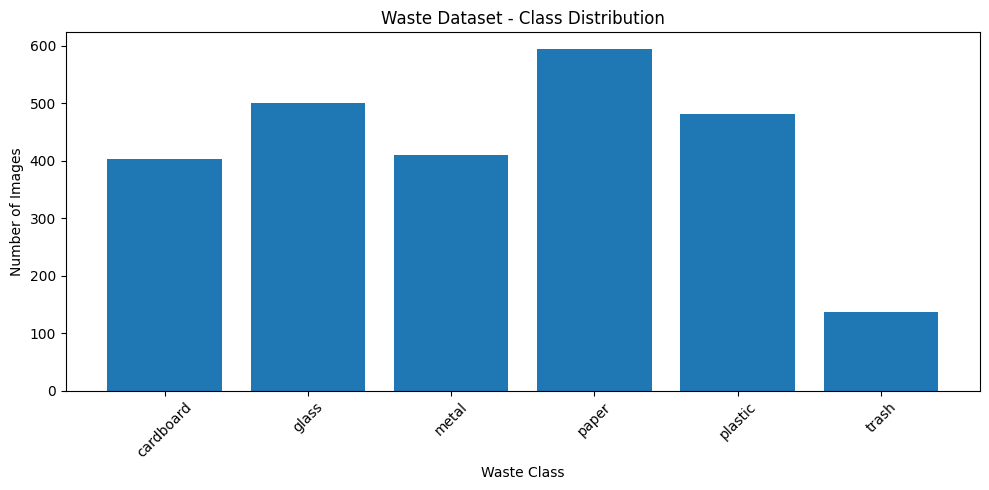

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Image_Count"]
)

plt.title("Waste Dataset - Class Distribution")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Paper has the most images, while Trash has the fewest images.

In [8]:
# Select the first image from the cardboard class

sample_class = "cardboard"

sample_class_path = os.path.join(
    data_path,
    sample_class
)

sample_image_name = os.listdir(sample_class_path)[0]

sample_image_path = os.path.join(
    sample_class_path,
    sample_image_name
)

image = Image.open(sample_image_path)

print("Image name:", sample_image_name)
print("Image format:", image.format)
print("Image size:", image.size)
print("Image mode:", image.mode)

Image name: cardboard1.jpg
Image format: JPEG
Image size: (512, 384)
Image mode: RGB


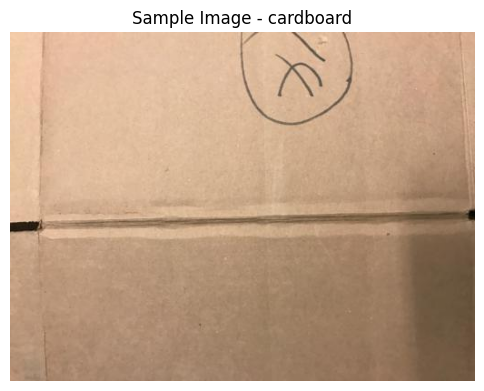

In [9]:
plt.figure(figsize=(6, 5))

plt.imshow(image)

plt.title(f"Sample Image - {sample_class}")

plt.axis("off")

plt.show()

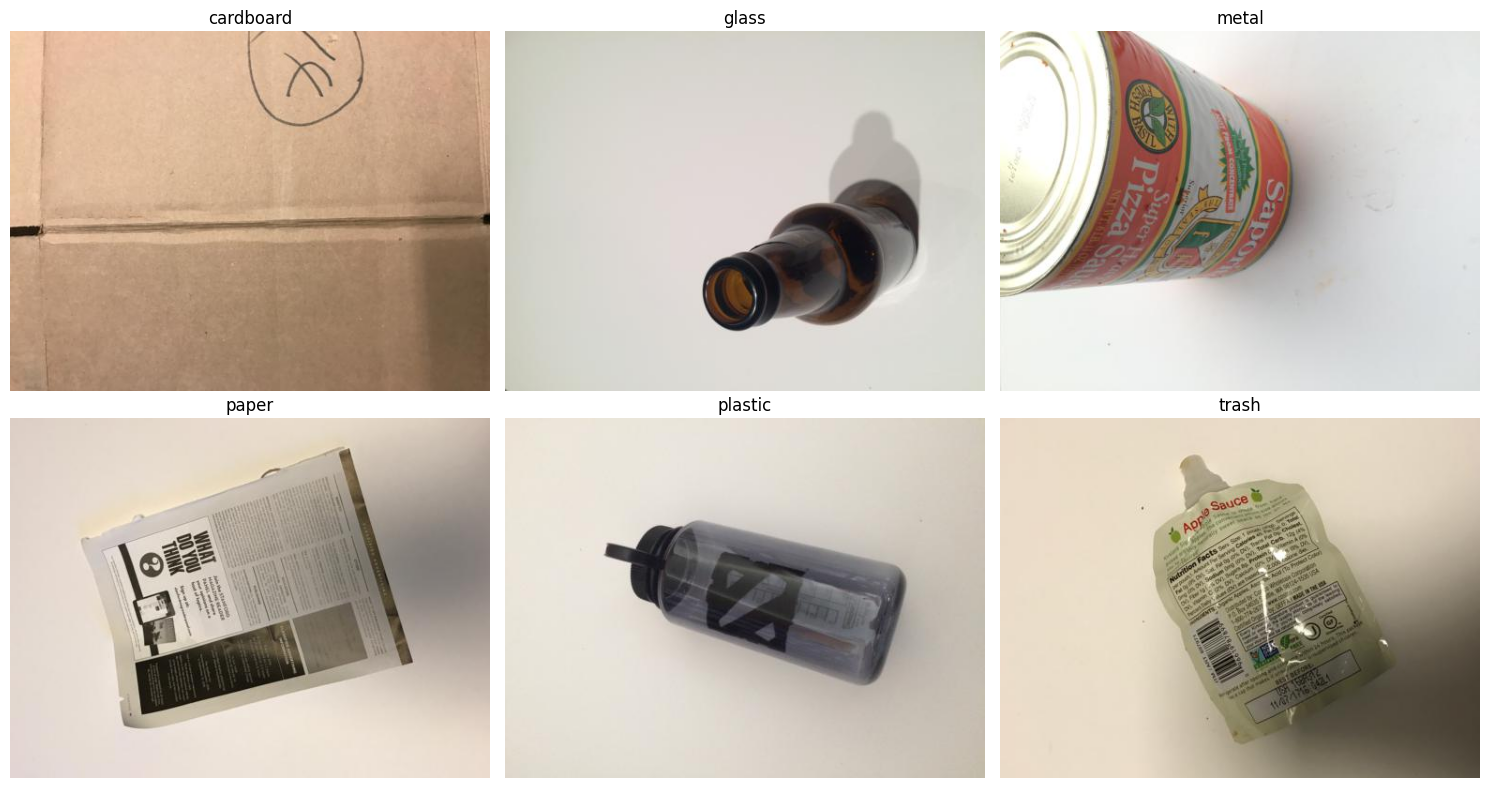

In [10]:
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    
    class_path = os.path.join(data_path, class_name)
    
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    image_path = os.path.join(
        class_path,
        image_files[0]
    )
    
    image = Image.open(image_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
image_dimensions = []

for class_name in classes:
    
    class_path = os.path.join(data_path, class_name)
    
    for file_name in os.listdir(class_path):
        
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            
            image_path = os.path.join(
                class_path,
                file_name
            )
            
            try:
                image = Image.open(image_path)
                
                width, height = image.size
                
                image_dimensions.append({
                    "Class": class_name,
                    "File": file_name,
                    "Width": width,
                    "Height": height
                })
                
            except Exception as e:
                print("Error reading:", image_path)

In [12]:
dimensions_df = pd.DataFrame(image_dimensions)

dimensions_df.head()

,Class,File,Width,Height
0,cardboard,cardboard1.jpg,512,384
1,cardboard,cardboard10.jpg,512,384
2,cardboard,cardboard100.jpg,512,384
3,cardboard,cardboard101.jpg,512,384
4,cardboard,cardboard102.jpg,512,384


In [13]:
unique_dimensions = dimensions_df[
    ["Width", "Height"]
].drop_duplicates()

print("Unique image dimensions:")
print(unique_dimensions)

Unique image dimensions:
   Width  Height
0    512     384


In [14]:
image_modes = []

for class_name in classes:
    
    class_path = os.path.join(data_path, class_name)
    
    for file_name in os.listdir(class_path):
        
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            
            image_path = os.path.join(
                class_path,
                file_name
            )
            
            try:
                image = Image.open(image_path)
                
                image_modes.append({
                    "Class": class_name,
                    "File": file_name,
                    "Mode": image.mode
                })
                
            except Exception:
                pass

modes_df = pd.DataFrame(image_modes)

print(modes_df["Mode"].value_counts())

Mode
RGB    2527
Name: count, dtype: int64


In [15]:
corrupted_images = []

for class_name in classes:
    
    class_path = os.path.join(data_path, class_name)
    
    for file_name in os.listdir(class_path):
        
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            
            image_path = os.path.join(
                class_path,
                file_name
            )
            
            try:
                with Image.open(image_path) as img:
                    img.verify()
                    
            except Exception:
                corrupted_images.append(image_path)

print("Number of corrupted images:", len(corrupted_images))

if len(corrupted_images) > 0:
    print("\nCorrupted files:")
    for file in corrupted_images:
        print(file)

Number of corrupted images: 0


In [16]:
print("========== DATASET SUMMARY ==========")
print("Dataset name: TrashNet")
print("Number of classes:", len(classes))
print("Total images:", total_images)

print("\nClasses:")
for class_name in classes:
    print(f"- {class_name}: {class_counts[class_name]} images")

print("\nLargest class:")
print(
    f"{largest_class['Class']} - "
    f"{largest_class['Image_Count']} images"
)

print("\nSmallest class:")
print(
    f"{smallest_class['Class']} - "
    f"{smallest_class['Image_Count']} images"
)

print("\nCorrupted images:", len(corrupted_images))

print("\n======================================")

========== DATASET SUMMARY ==========
Dataset name: TrashNet
Number of classes: 6
Total images: 2527

Classes:
- cardboard: 403 images
- glass: 501 images
- metal: 410 images
- paper: 594 images
- plastic: 482 images
- trash: 137 images

Largest class:
paper - 594 images

Smallest class:
trash - 137 images

Corrupted images: 0

